# Credit Card Transactions — Exploratory Data Analysis
**Project:** Customer Spending Intelligence | Fintech Portfolio Project  
**Dataset:** Credit Card Transactions Dataset — priyamchoksi (Kaggle) — 1.85M rows, 23 columns  
**Author:** Shrey Sheth  

---

## Dataset Schema
| Column | Type | Description |
|---|---|---|
| `trans_date_trans_time` | datetime | Timestamp of transaction |
| `cc_num` | int | Credit card number (anonymized) |
| `merchant` | str | Merchant name |
| `category` | str | Merchant category (grocery, entertainment, etc.) |
| `amt` | float | Transaction amount (USD) |
| `first`, `last` | str | Cardholder name |
| `gender` | str | Cardholder gender |
| `city`, `state`, `zip` | str | Cardholder location |
| `lat`, `long` | float | Cardholder coordinates |
| `city_pop` | int | Population of cardholder's city |
| `job` | str | Cardholder occupation |
| `dob` | date | Date of birth |
| `trans_num` | str | Unique transaction ID |
| `unix_time` | int | Unix timestamp |
| `merch_lat`, `merch_long` | float | Merchant coordinates |
| `is_fraud` | int | Target: 1 = fraud, 0 = legitimate |

## Key Questions
1. What does the overall transaction landscape look like?
2. How does spending vary by category, time of day, and day of week?
3. What is the fraud rate, and how does it distribute across categories and demographics?
4. What behavioral features separate fraudulent from legitimate transactions?
5. What features can we engineer for RFM segmentation and modeling?

---
## 0. Setup & Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (13, 5)
warnings.filterwarnings('ignore')

import os
os.makedirs('plots', exist_ok=True)

print('Setup complete.')

Setup complete.


---
## 1. Load & First Look

> **Note:** This dataset is ~120MB with 1.85M rows. We parse dates at load time and sample if needed for faster iteration during development.

In [4]:
# Load dataset — update filename if yours differs
df = pd.read_csv(
    'credit_card_transactions.csv',
    parse_dates=['trans_date_trans_time', 'dob']
)

# Drop the unnamed index column if present
if 'Unnamed: 0' in df.columns:
    df.drop(columns=['Unnamed: 0'], inplace=True)

print(f'Shape: {df.shape}')
print(f'Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
df.head()

Shape: (1296675, 23)
Memory usage: 941.3 MB


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.08,-81.18,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.01,-82.05,0,"28,705.00"
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.89,-118.21,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.16,-118.19,0,NaN
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.18,-112.26,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.15,-112.15,0,"83,236.00"
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.23,-112.11,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.03,-112.56,0,NaN
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.42,-79.46,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.67,-78.63,0,"22,844.00"


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype         
---  ------                 --------------    -----         
 0   trans_date_trans_time  1296675 non-null  datetime64[ns]
 1   cc_num                 1296675 non-null  int64         
 2   merchant               1296675 non-null  object        
 3   category               1296675 non-null  object        
 4   amt                    1296675 non-null  float64       
 5   first                  1296675 non-null  object        
 6   last                   1296675 non-null  object        
 7   gender                 1296675 non-null  object        
 8   street                 1296675 non-null  object        
 9   city                   1296675 non-null  object        
 10  state                  1296675 non-null  object        
 11  zip                    1296675 non-null  int64         
 12  lat                    12966

In [6]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
trans_date_trans_time,1296675,2019-10-03 12:47:28.070214144,2019-01-01 00:00:18,2019-06-03 19:12:22.500000,2019-10-03 07:35:47,2020-01-28 15:02:55.500000,2020-06-21 12:13:37,NaN
cc_num,"1,296,675.00","417,192,042,079,726,656.00","60,416,207,185.00","180,042,946,491,150.00","3,521,417,320,836,166.00","4,642,255,475,285,942.00","4,992,346,398,065,154,048.00","1,308,806,447,000,789,248.00"
amt,"1,296,675.00",70.35,1.00,9.65,47.52,83.14,"28,948.90",160.32
zip,"1,296,675.00","48,800.67","1,257.00","26,237.00","48,174.00","72,042.00","99,783.00","26,893.22"
lat,"1,296,675.00",38.54,20.03,34.62,39.35,41.94,66.69,5.08
long,"1,296,675.00",-90.23,-165.67,-96.80,-87.48,-80.16,-67.95,13.76
city_pop,"1,296,675.00","88,824.44",23.00,743.00,"2,456.00","20,328.00","2,906,700.00","301,956.36"
dob,1296675,1973-10-03 19:02:55.017178512,1924-10-30 00:00:00,1962-08-13 00:00:00,1975-11-30 00:00:00,1987-02-22 00:00:00,2005-01-29 00:00:00,NaN
unix_time,"1,296,675.00","1,349,243,636.73","1,325,376,018.00","1,338,750,742.50","1,349,249,747.00","1,359,385,375.50","1,371,816,817.00","12,841,278.42"
merch_lat,"1,296,675.00",38.54,19.03,34.73,39.37,41.96,67.51,5.11


---
## 2. Data Quality Check

In [7]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Count': missing, 'Percent': missing_pct}).sort_values('Percent', ascending=False)

print('=== Missing Value Audit ===')
has_missing = missing_df[missing_df['Count'] > 0]
print(has_missing if len(has_missing) > 0 else 'No missing values — clean dataset.')

=== Missing Value Audit ===
                Count  Percent
merch_zipcode  195973    15.11


In [8]:
# Duplicates
print(f'Duplicate rows: {df.duplicated().sum()}')
print(f'Duplicate transaction IDs: {df["trans_num"].duplicated().sum()}')

# Categorical cardinality
cat_cols = ['merchant', 'category', 'gender', 'state', 'job']
for col in cat_cols:
    print(f'  {col}: {df[col].nunique()} unique values')

Duplicate rows: 0
Duplicate transaction IDs: 0
  merchant: 693 unique values
  category: 14 unique values
  gender: 2 unique values
  state: 51 unique values
  job: 494 unique values


In [9]:
# Transaction amount sanity check — negative or zero amounts?
print(f'Zero or negative amounts: {(df["amt"] <= 0).sum()}')
print(f'Transactions > $1,000: {(df["amt"] > 1000).sum()} ({(df["amt"] > 1000).mean()*100:.2f}%)')
print(f'Transaction amount range: ${df["amt"].min():.2f} — ${df["amt"].max():.2f}')

Zero or negative amounts: 0
Transactions > $1,000: 3936 (0.30%)
Transaction amount range: $1.00 — $28948.90


---
## 3. Feature Engineering — Time Features

> **Why this matters:** Raw timestamps are useless to models. Extracting hour, day, month gives us temporal signal that is extremely predictive — fraud patterns cluster at night, spending peaks on weekends, etc. This is the kind of feature engineering that separates strong candidates from tutorial-followers.

In [10]:
# Extract time features from transaction timestamp
df['trans_hour']    = df['trans_date_trans_time'].dt.hour
df['trans_day']     = df['trans_date_trans_time'].dt.day_name()
df['trans_month']   = df['trans_date_trans_time'].dt.month
df['trans_year']    = df['trans_date_trans_time'].dt.year
df['trans_dow']     = df['trans_date_trans_time'].dt.dayofweek   # 0=Mon, 6=Sun
df['is_weekend']    = df['trans_dow'].isin([5, 6]).astype(int)

# Customer age at time of transaction
df['customer_age'] = (
    (df['trans_date_trans_time'] - df['dob']).dt.days / 365.25
).astype(int)

# Distance between customer and merchant (Haversine approximation)
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in km
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

df['distance_km'] = haversine_distance(
    df['lat'], df['long'], df['merch_lat'], df['merch_long']
)

print('Time features engineered:')
print(df[['trans_date_trans_time', 'trans_hour', 'trans_day', 'customer_age', 'distance_km']].head())

Time features engineered:
  trans_date_trans_time  trans_hour trans_day  customer_age  distance_km
0   2019-01-01 00:00:18           0   Tuesday            30        78.60
1   2019-01-01 00:00:44           0   Tuesday            40        30.21
2   2019-01-01 00:00:51           0   Tuesday            56       108.21
3   2019-01-01 00:01:16           0   Tuesday            51        95.67
4   2019-01-01 00:03:06           0   Tuesday            32        77.56


---
## 4. Target Variable — Fraud Distribution

> **Critical note for write-up:** The fraud rate here is under 1%. This is extreme class imbalance. A model that predicts 'not fraud' for every transaction would be 99%+ accurate — and completely useless. This is why we will use **Precision-Recall AUC** as our primary evaluation metric in Phase 3, not accuracy.

Total transactions: 1,296,675
Fraudulent:  7,506 (0.58%)
Legitimate:  1,289,169 (99.42%)


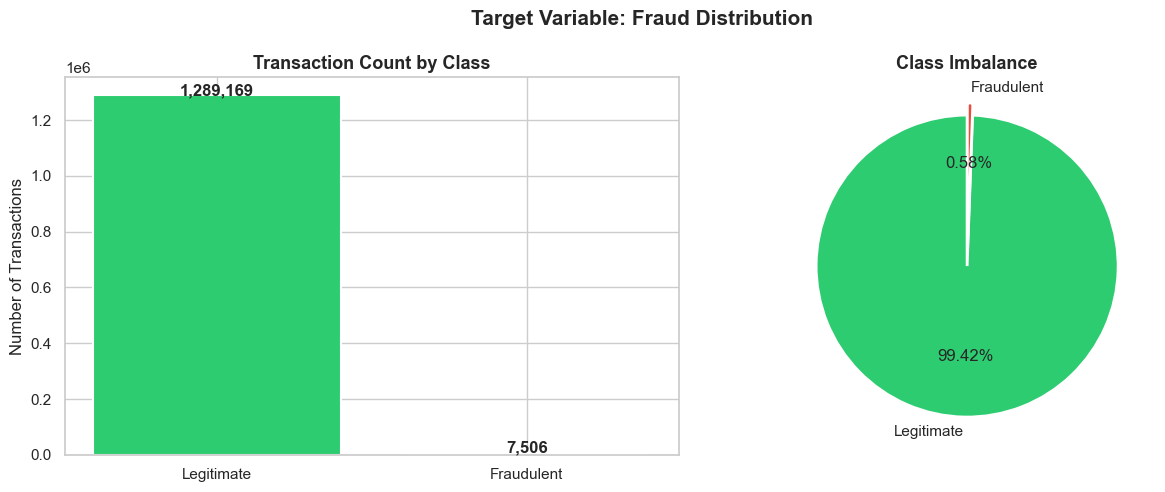

In [11]:
fraud_rate = df['is_fraud'].mean() * 100
fraud_counts = df['is_fraud'].value_counts()

print(f'Total transactions: {len(df):,}')
print(f'Fraudulent:  {fraud_counts[1]:,} ({fraud_rate:.2f}%)')
print(f'Legitimate:  {fraud_counts[0]:,} ({100-fraud_rate:.2f}%)')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(['Legitimate', 'Fraudulent'], fraud_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Transaction Count by Class', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Transactions')
for i, v in enumerate(fraud_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(
    fraud_counts.values,
    labels=['Legitimate', 'Fraudulent'],
    autopct='%1.2f%%',
    colors=['#2ecc71', '#e74c3c'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
    explode=[0, 0.08]
)
axes[1].set_title('Class Imbalance', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable: Fraud Distribution', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/01_fraud_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 5. Transaction Amount Analysis

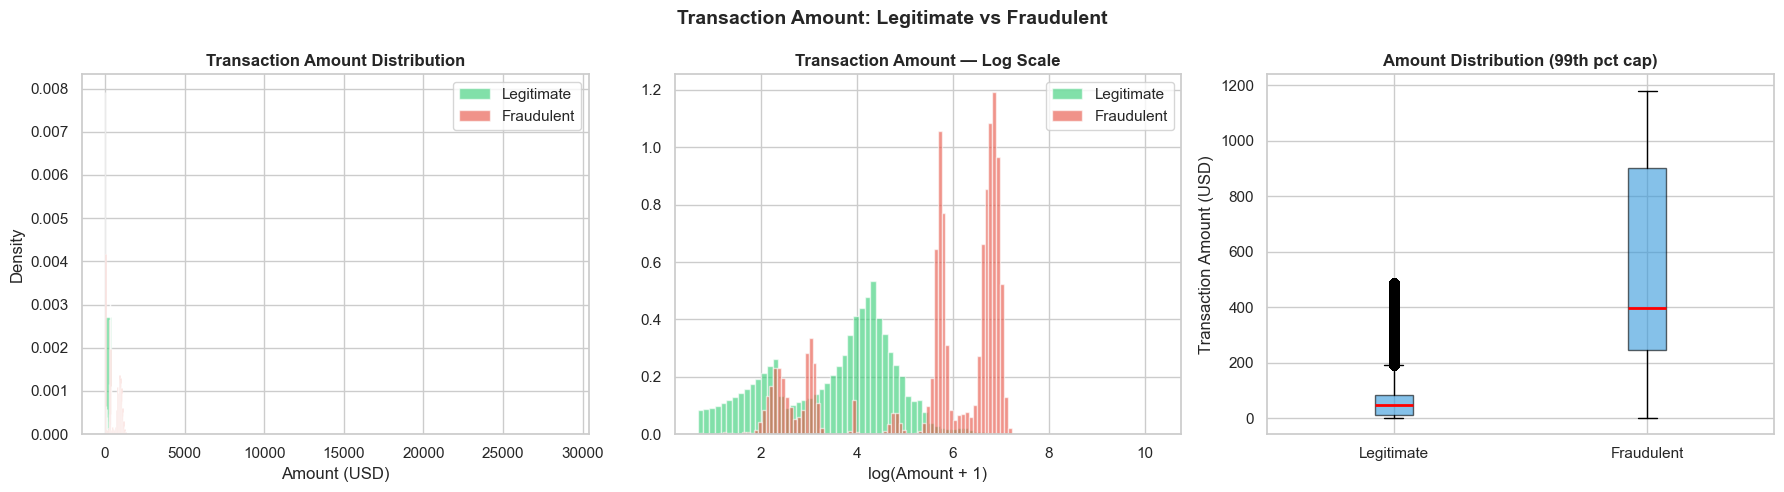

Median amount — Legitimate: $47.28
Median amount — Fraudulent: $396.50


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribution of transaction amount (log scale for skew)
legit  = df[df['is_fraud'] == 0]['amt']
fraud  = df[df['is_fraud'] == 1]['amt']

axes[0].hist(legit, bins=80, alpha=0.6, color='#2ecc71', label='Legitimate', density=True)
axes[0].hist(fraud, bins=80, alpha=0.6, color='#e74c3c', label='Fraudulent', density=True)
axes[0].set_title('Transaction Amount Distribution', fontweight='bold')
axes[0].set_xlabel('Amount (USD)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Same on log scale to see the tail
axes[1].hist(np.log1p(legit), bins=80, alpha=0.6, color='#2ecc71', label='Legitimate', density=True)
axes[1].hist(np.log1p(fraud), bins=80, alpha=0.6, color='#e74c3c', label='Fraudulent', density=True)
axes[1].set_title('Transaction Amount — Log Scale', fontweight='bold')
axes[1].set_xlabel('log(Amount + 1)')
axes[1].legend()

# Box plot comparison
axes[2].boxplot(
    [legit.clip(upper=legit.quantile(0.99)), fraud.clip(upper=fraud.quantile(0.99))],
    labels=['Legitimate', 'Fraudulent'],
    patch_artist=True,
    boxprops=dict(facecolor='#3498db', alpha=0.6),
    medianprops=dict(color='red', linewidth=2)
)
axes[2].set_title('Amount Distribution (99th pct cap)', fontweight='bold')
axes[2].set_ylabel('Transaction Amount (USD)')

plt.suptitle('Transaction Amount: Legitimate vs Fraudulent', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/02_amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Median amount — Legitimate: ${legit.median():.2f}')
print(f'Median amount — Fraudulent: ${fraud.median():.2f}')

---
## 6. Spending by Category

> Merchant category is one of the richest features in this dataset. Understanding which categories drive volume vs. which drive fraud risk is exactly the kind of insight a fintech analyst would be asked to surface.

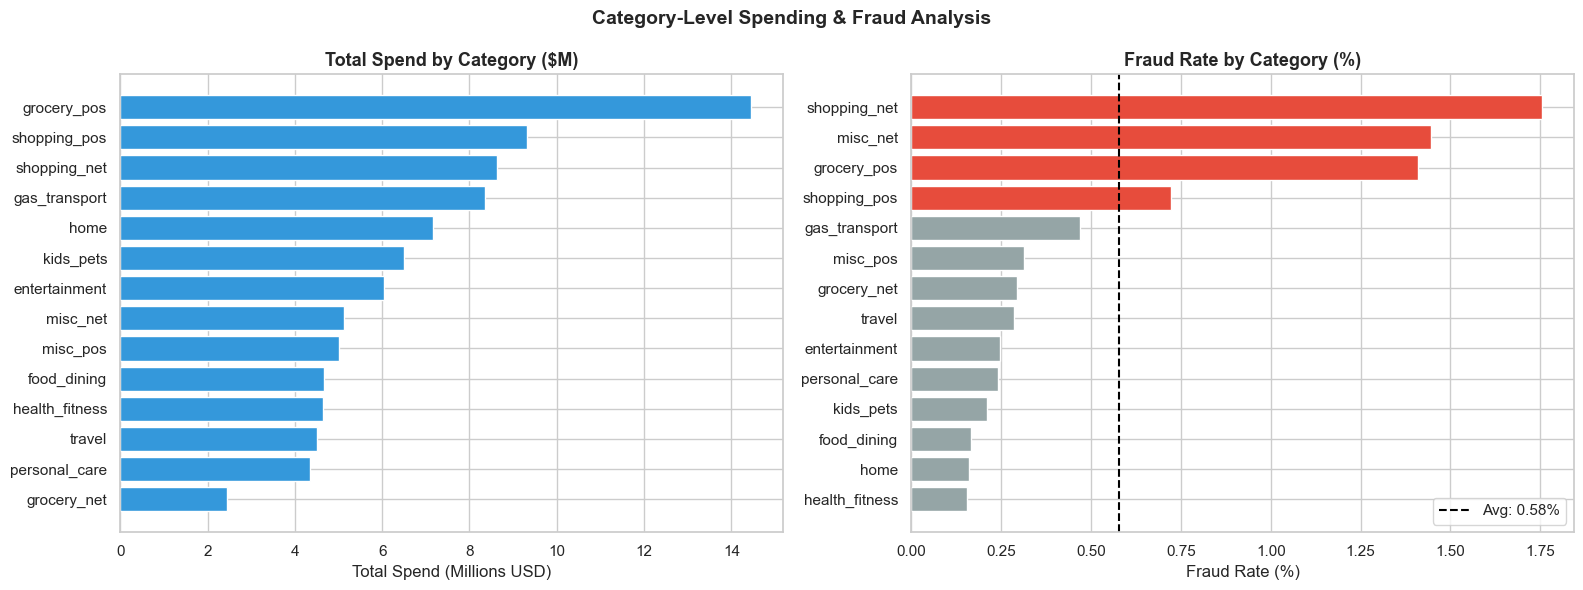

      category  txn_count   total_spend  avg_amount  fraud_rate_pct
   grocery_pos     123638 14,460,822.38      116.96            1.41
  shopping_pos     116672  9,307,993.61       79.78            0.72
  shopping_net      97543  8,625,149.68       88.42            1.76
 gas_transport     131659  8,351,732.29       63.43            0.47
          home     123115  7,173,928.11       58.27            0.16
     kids_pets     113035  6,503,680.16       57.54            0.21
 entertainment      94014  6,036,678.56       64.21            0.25
      misc_net      63287  5,117,709.26       80.87            1.45
      misc_pos      79655  5,009,582.50       62.89            0.31
   food_dining      91461  4,672,459.44       51.09            0.17
health_fitness      85879  4,653,108.02       54.18            0.15
        travel      40507  4,516,721.68      111.50            0.29
 personal_care      90758  4,353,450.53       47.97            0.24
   grocery_net      45452  2,439,412.68       53

In [13]:
# Total transaction volume by category
cat_volume = df.groupby('category').agg(
    total_spend = ('amt', 'sum'),
    txn_count   = ('amt', 'count'),
    avg_amount  = ('amt', 'mean'),
    fraud_rate  = ('is_fraud', 'mean')
).sort_values('total_spend', ascending=False).reset_index()

cat_volume['fraud_rate_pct'] = cat_volume['fraud_rate'] * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Total spend by category
bars = axes[0].barh(cat_volume['category'], cat_volume['total_spend'] / 1e6,
                    color='#3498db', edgecolor='white')
axes[0].set_title('Total Spend by Category ($M)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Spend (Millions USD)')
axes[0].invert_yaxis()

# Fraud rate by category
colors = ['#e74c3c' if x > fraud_rate else '#95a5a6' for x in cat_volume.sort_values('fraud_rate_pct')['fraud_rate_pct']]
cat_sorted = cat_volume.sort_values('fraud_rate_pct')
axes[1].barh(cat_sorted['category'], cat_sorted['fraud_rate_pct'], color=colors, edgecolor='white')
axes[1].axvline(fraud_rate, color='black', linestyle='--', linewidth=1.5, label=f'Avg: {fraud_rate:.2f}%')
axes[1].set_title('Fraud Rate by Category (%)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Fraud Rate (%)')
axes[1].legend()

plt.suptitle('Category-Level Spending & Fraud Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/03_category_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(cat_volume[['category', 'txn_count', 'total_spend', 'avg_amount', 'fraud_rate_pct']].to_string(index=False))

---
## 7. Temporal Patterns — When Do Transactions (and Fraud) Happen?

> Time-of-day and day-of-week patterns are classic fintech EDA. Fraud often clusters in late-night hours when real cardholders are asleep. This section visualizes that.

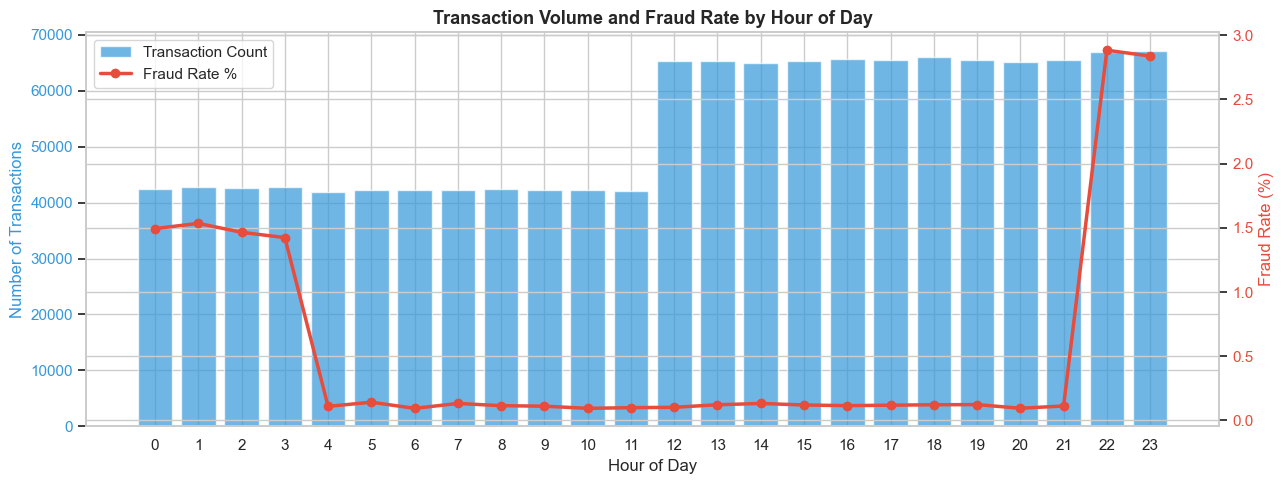

In [14]:
# Transactions and fraud rate by hour of day
hourly = df.groupby('trans_hour').agg(
    txn_count  = ('amt', 'count'),
    fraud_rate = ('is_fraud', 'mean')
).reset_index()

fig, ax1 = plt.subplots(figsize=(13, 5))

ax1.bar(hourly['trans_hour'], hourly['txn_count'], color='#3498db', alpha=0.7, label='Transaction Count')
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Number of Transactions', color='#3498db')
ax1.tick_params(axis='y', labelcolor='#3498db')
ax1.set_xticks(range(0, 24))

ax2 = ax1.twinx()
ax2.plot(hourly['trans_hour'], hourly['fraud_rate'] * 100, color='#e74c3c',
         marker='o', linewidth=2.5, markersize=6, label='Fraud Rate %')
ax2.set_ylabel('Fraud Rate (%)', color='#e74c3c')
ax2.tick_params(axis='y', labelcolor='#e74c3c')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Transaction Volume and Fraud Rate by Hour of Day', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/04_hourly_pattern.png', dpi=150, bbox_inches='tight')
plt.show()

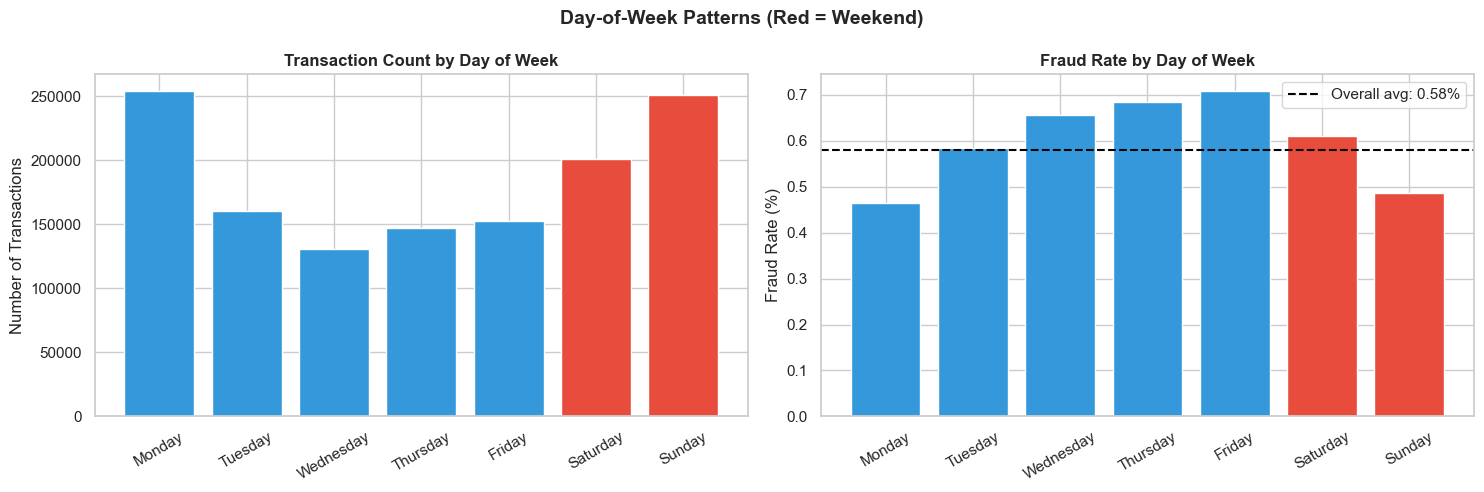

In [15]:
# Day of week pattern
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

daily = df.groupby('trans_day').agg(
    txn_count  = ('amt', 'count'),
    total_spend= ('amt', 'sum'),
    fraud_rate = ('is_fraud', 'mean')
).reindex(day_order).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

colors_day = ['#e74c3c' if d in ['Saturday', 'Sunday'] else '#3498db' for d in daily['trans_day']]
axes[0].bar(daily['trans_day'], daily['txn_count'], color=colors_day, edgecolor='white')
axes[0].set_title('Transaction Count by Day of Week', fontweight='bold')
axes[0].set_ylabel('Number of Transactions')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(daily['trans_day'], daily['fraud_rate'] * 100, color=colors_day, edgecolor='white')
axes[1].axhline(fraud_rate, color='black', linestyle='--', linewidth=1.5, label=f'Overall avg: {fraud_rate:.2f}%')
axes[1].set_title('Fraud Rate by Day of Week', fontweight='bold')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()

plt.suptitle('Day-of-Week Patterns (Red = Weekend)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/05_daily_pattern.png', dpi=150, bbox_inches='tight')
plt.show()

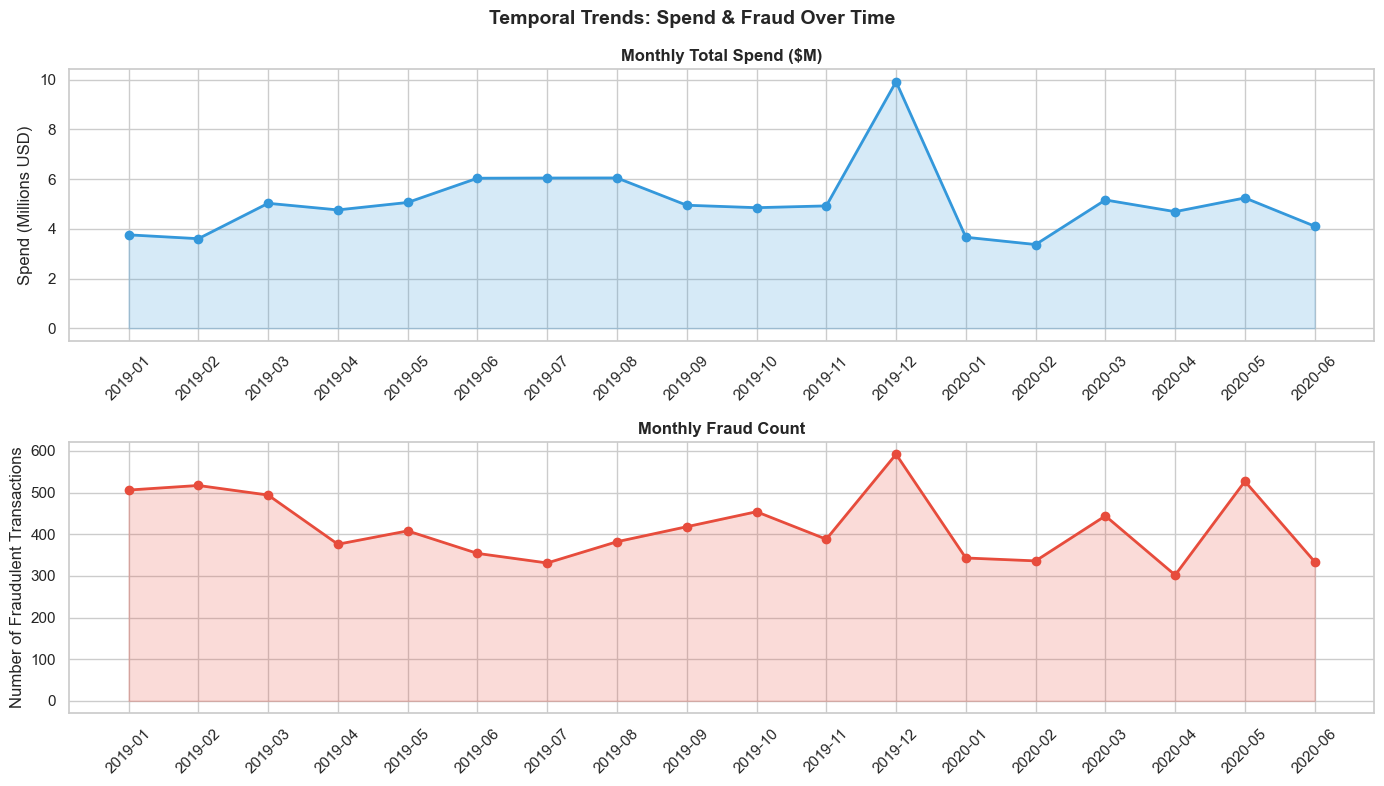

In [16]:
# Monthly trend — transaction volume over time
df['year_month'] = df['trans_date_trans_time'].dt.to_period('M')

monthly = df.groupby('year_month').agg(
    txn_count  = ('amt', 'count'),
    total_spend= ('amt', 'sum'),
    fraud_count= ('is_fraud', 'sum')
).reset_index()
monthly['year_month'] = monthly['year_month'].astype(str)

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(monthly['year_month'], monthly['total_spend'] / 1e6, marker='o', color='#3498db', linewidth=2)
axes[0].fill_between(monthly['year_month'], monthly['total_spend'] / 1e6, alpha=0.2, color='#3498db')
axes[0].set_title('Monthly Total Spend ($M)', fontweight='bold')
axes[0].set_ylabel('Spend (Millions USD)')
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(monthly['year_month'], monthly['fraud_count'], marker='o', color='#e74c3c', linewidth=2)
axes[1].fill_between(monthly['year_month'], monthly['fraud_count'], alpha=0.2, color='#e74c3c')
axes[1].set_title('Monthly Fraud Count', fontweight='bold')
axes[1].set_ylabel('Number of Fraudulent Transactions')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Temporal Trends: Spend & Fraud Over Time', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/06_monthly_trends.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Customer Demographics & Spending Behavior

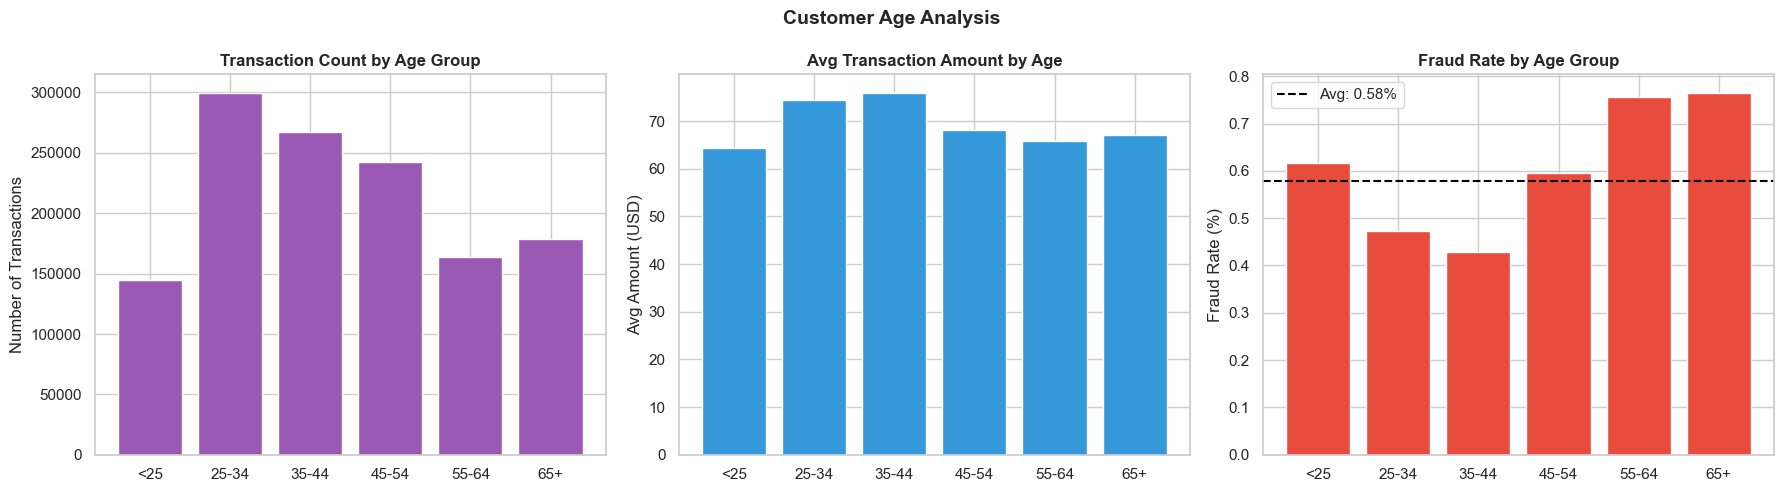

In [17]:
# Age distribution and fraud rate by age group
df['age_group'] = pd.cut(
    df['customer_age'],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=['<25', '25-34', '35-44', '45-54', '55-64', '65+']
)

age_stats = df.groupby('age_group').agg(
    txn_count  = ('amt', 'count'),
    avg_spend  = ('amt', 'mean'),
    fraud_rate = ('is_fraud', 'mean')
).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].bar(age_stats['age_group'], age_stats['txn_count'], color='#9b59b6', edgecolor='white')
axes[0].set_title('Transaction Count by Age Group', fontweight='bold')
axes[0].set_ylabel('Number of Transactions')

axes[1].bar(age_stats['age_group'], age_stats['avg_spend'], color='#3498db', edgecolor='white')
axes[1].set_title('Avg Transaction Amount by Age', fontweight='bold')
axes[1].set_ylabel('Avg Amount (USD)')

axes[2].bar(age_stats['age_group'], age_stats['fraud_rate'] * 100, color='#e74c3c', edgecolor='white')
axes[2].axhline(fraud_rate, color='black', linestyle='--', linewidth=1.5, label=f'Avg: {fraud_rate:.2f}%')
axes[2].set_title('Fraud Rate by Age Group', fontweight='bold')
axes[2].set_ylabel('Fraud Rate (%)')
axes[2].legend()

plt.suptitle('Customer Age Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/07_age_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# Gender breakdown
gender_stats = df.groupby('gender').agg(
    txn_count  = ('amt', 'count'),
    avg_spend  = ('amt', 'mean'),
    fraud_rate = ('is_fraud', 'mean')
).reset_index()

print('=== Gender Stats ===')
gender_stats['fraud_rate_pct'] = gender_stats['fraud_rate'] * 100
print(gender_stats[['gender', 'txn_count', 'avg_spend', 'fraud_rate_pct']].to_string(index=False))

=== Gender Stats ===
gender  txn_count  avg_spend  fraud_rate_pct
     F     709863      70.20            0.53
     M     586812      70.53            0.64


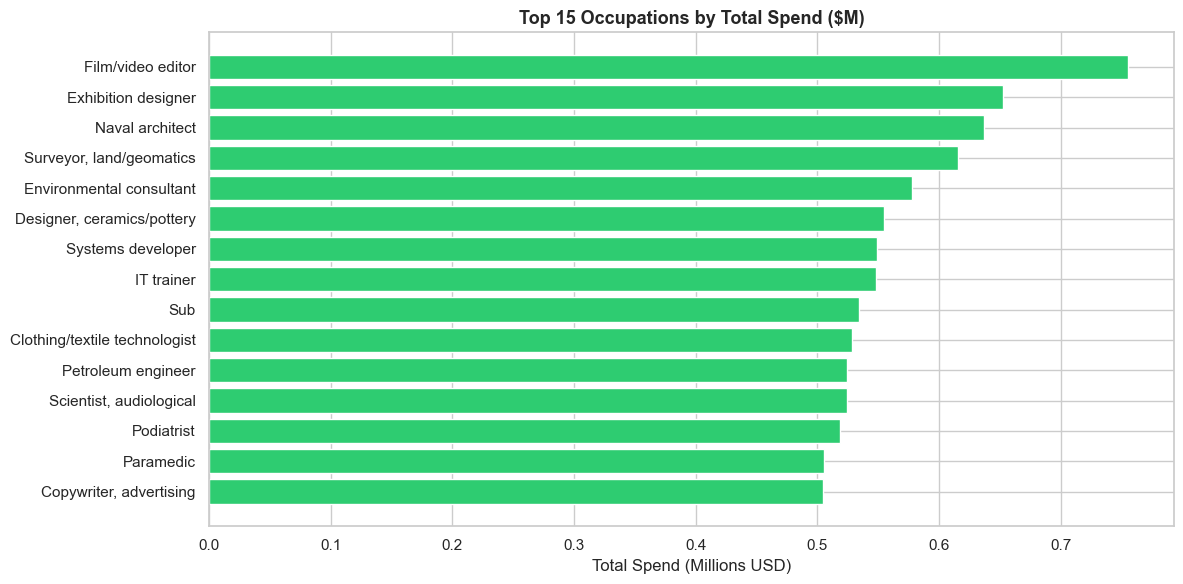

In [19]:
# Top jobs by transaction volume
top_jobs = df.groupby('job')['amt'].agg(['sum', 'count', 'mean']).sort_values('sum', ascending=False).head(15)
top_jobs.columns = ['total_spend', 'txn_count', 'avg_spend']

plt.figure(figsize=(12, 6))
plt.barh(top_jobs.index[::-1], top_jobs['total_spend'][::-1] / 1e6, color='#2ecc71', edgecolor='white')
plt.title('Top 15 Occupations by Total Spend ($M)', fontsize=13, fontweight='bold')
plt.xlabel('Total Spend (Millions USD)')
plt.tight_layout()
plt.savefig('plots/08_job_spend.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Distance Analysis — Fraud Geography

> Distance between cardholder and merchant is a powerful fraud signal. A transaction 800km from the cardholder's home at 2am is very different from one at the local grocery store.

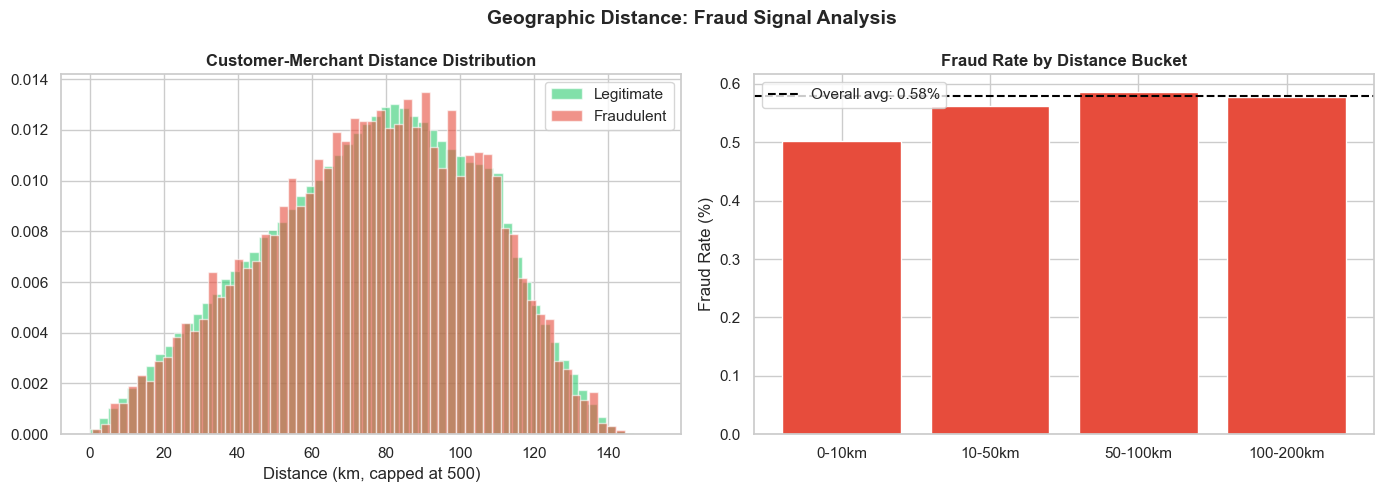

Median distance — Legitimate: 78.2 km
Median distance — Fraudulent: 77.9 km


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

legit_dist = df[df['is_fraud'] == 0]['distance_km'].clip(upper=500)
fraud_dist = df[df['is_fraud'] == 1]['distance_km'].clip(upper=500)

axes[0].hist(legit_dist, bins=60, alpha=0.6, color='#2ecc71', label='Legitimate', density=True)
axes[0].hist(fraud_dist, bins=60, alpha=0.6, color='#e74c3c', label='Fraudulent', density=True)
axes[0].set_title('Customer-Merchant Distance Distribution', fontweight='bold')
axes[0].set_xlabel('Distance (km, capped at 500)')
axes[0].legend()

# Fraud rate by distance bucket
df['dist_bucket'] = pd.cut(df['distance_km'], bins=[0, 10, 50, 100, 200, 500, 10000],
                            labels=['0-10km', '10-50km', '50-100km', '100-200km', '200-500km', '500km+'])
dist_fraud = df.groupby('dist_bucket')['is_fraud'].mean() * 100

axes[1].bar(dist_fraud.index, dist_fraud.values, color='#e74c3c', edgecolor='white')
axes[1].axhline(fraud_rate, color='black', linestyle='--', linewidth=1.5, label=f'Overall avg: {fraud_rate:.2f}%')
axes[1].set_title('Fraud Rate by Distance Bucket', fontweight='bold')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].legend()

plt.suptitle('Geographic Distance: Fraud Signal Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/09_distance_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Median distance — Legitimate: {legit_dist.median():.1f} km')
print(f'Median distance — Fraudulent: {fraud_dist.median():.1f} km')

---
## 10. Per-Customer Aggregation — Building RFM Foundation

> This section collapses from transaction level to customer level. These aggregated features become the input to Phase 2 (RFM clustering) and Phase 3 (churn/fraud modeling). This is a critical step — this is what real fintech data pipelines do.

In [21]:
# Snapshot date = max transaction date in dataset
snapshot_date = df['trans_date_trans_time'].max()
print(f'Snapshot date (most recent transaction): {snapshot_date.date()}')

# Aggregate to customer level
customer_df = df.groupby('cc_num').agg(
    # RFM features
    recency         = ('trans_date_trans_time', lambda x: (snapshot_date - x.max()).days),  # days since last txn
    frequency       = ('trans_num', 'count'),          # total transactions
    monetary        = ('amt', 'sum'),                  # total spend
    # Behavioral features
    avg_txn_amt     = ('amt', 'mean'),
    max_txn_amt     = ('amt', 'max'),
    std_txn_amt     = ('amt', 'std'),
    unique_merchants= ('merchant', 'nunique'),
    unique_states   = ('state', 'nunique'),
    unique_categories = ('category', 'nunique'),
    night_txn_count = ('trans_hour', lambda x: (x < 6).sum()),  # transactions midnight-6am
    weekend_txn_count = ('is_weekend', 'sum'),
    avg_distance_km = ('distance_km', 'mean'),
    # Fraud flag (any fraudulent transaction = flagged customer)
    fraud_flag      = ('is_fraud', 'max'),
    fraud_txn_count = ('is_fraud', 'sum'),
    # Demographics (take first value — same per customer)
    gender          = ('gender', 'first'),
    state           = ('state', 'first'),
    customer_age    = ('customer_age', 'first'),
    city_pop        = ('city_pop', 'first'),
    job             = ('job', 'first')
).reset_index()

# Derived features
customer_df['night_txn_pct']   = customer_df['night_txn_count'] / customer_df['frequency']
customer_df['weekend_txn_pct'] = customer_df['weekend_txn_count'] / customer_df['frequency']

print(f'Customer-level dataset shape: {customer_df.shape}')
print(f'Fraudulent customers: {customer_df["fraud_flag"].sum()} ({customer_df["fraud_flag"].mean()*100:.1f}%)')
customer_df.head()

Snapshot date (most recent transaction): 2020-06-21
Customer-level dataset shape: (983, 22)
Fraudulent customers: 762 (77.5%)


,cc_num,recency,frequency,monetary,avg_txn_amt,max_txn_amt,std_txn_amt,unique_merchants,unique_states,unique_categories,night_txn_count,weekend_txn_count,avg_distance_km,fraud_flag,fraud_txn_count,gender,state,customer_age,city_pop,job,night_txn_pct,weekend_txn_pct
0,60416207185,0,1518,"85,043.47",56.02,"3,075.09",122.63,575,1,14,226,495,73.80,1,9,F,WY,32,1645,Information systems manager,0.15,0.33
1,60422928733,0,1531,"105,640.20",69.00,"1,290.37",102.68,578,1,14,469,516,79.17,1,12,M,SC,76,46944,Secondary school teacher,0.31,0.34
2,60423098130,2,510,"58,673.63",115.05,"27,119.77","1,202.99",338,1,14,111,171,77.28,1,10,M,OK,60,83,Barrister's clerk,0.22,0.34
3,60427851591,1,528,"59,129.61",111.99,"1,164.36",143.31,358,1,14,114,166,75.22,1,14,M,OK,42,2142,Politician's assistant,0.22,0.31
4,60487002085,0,496,"25,160.11",50.73,750.39,65.84,346,1,14,77,160,79.57,0,0,M,MS,46,233060,"Horticulturist, commercial",0.16,0.32


In [22]:
# Save customer-level dataset for use in Phase 2 & 3
customer_df.to_csv('customer_aggregated.csv', index=False)
print('Saved: customer_aggregated.csv — use this as input for Phase 2 (RFM) and Phase 3 (modeling)')

Saved: customer_aggregated.csv — use this as input for Phase 2 (RFM) and Phase 3 (modeling)


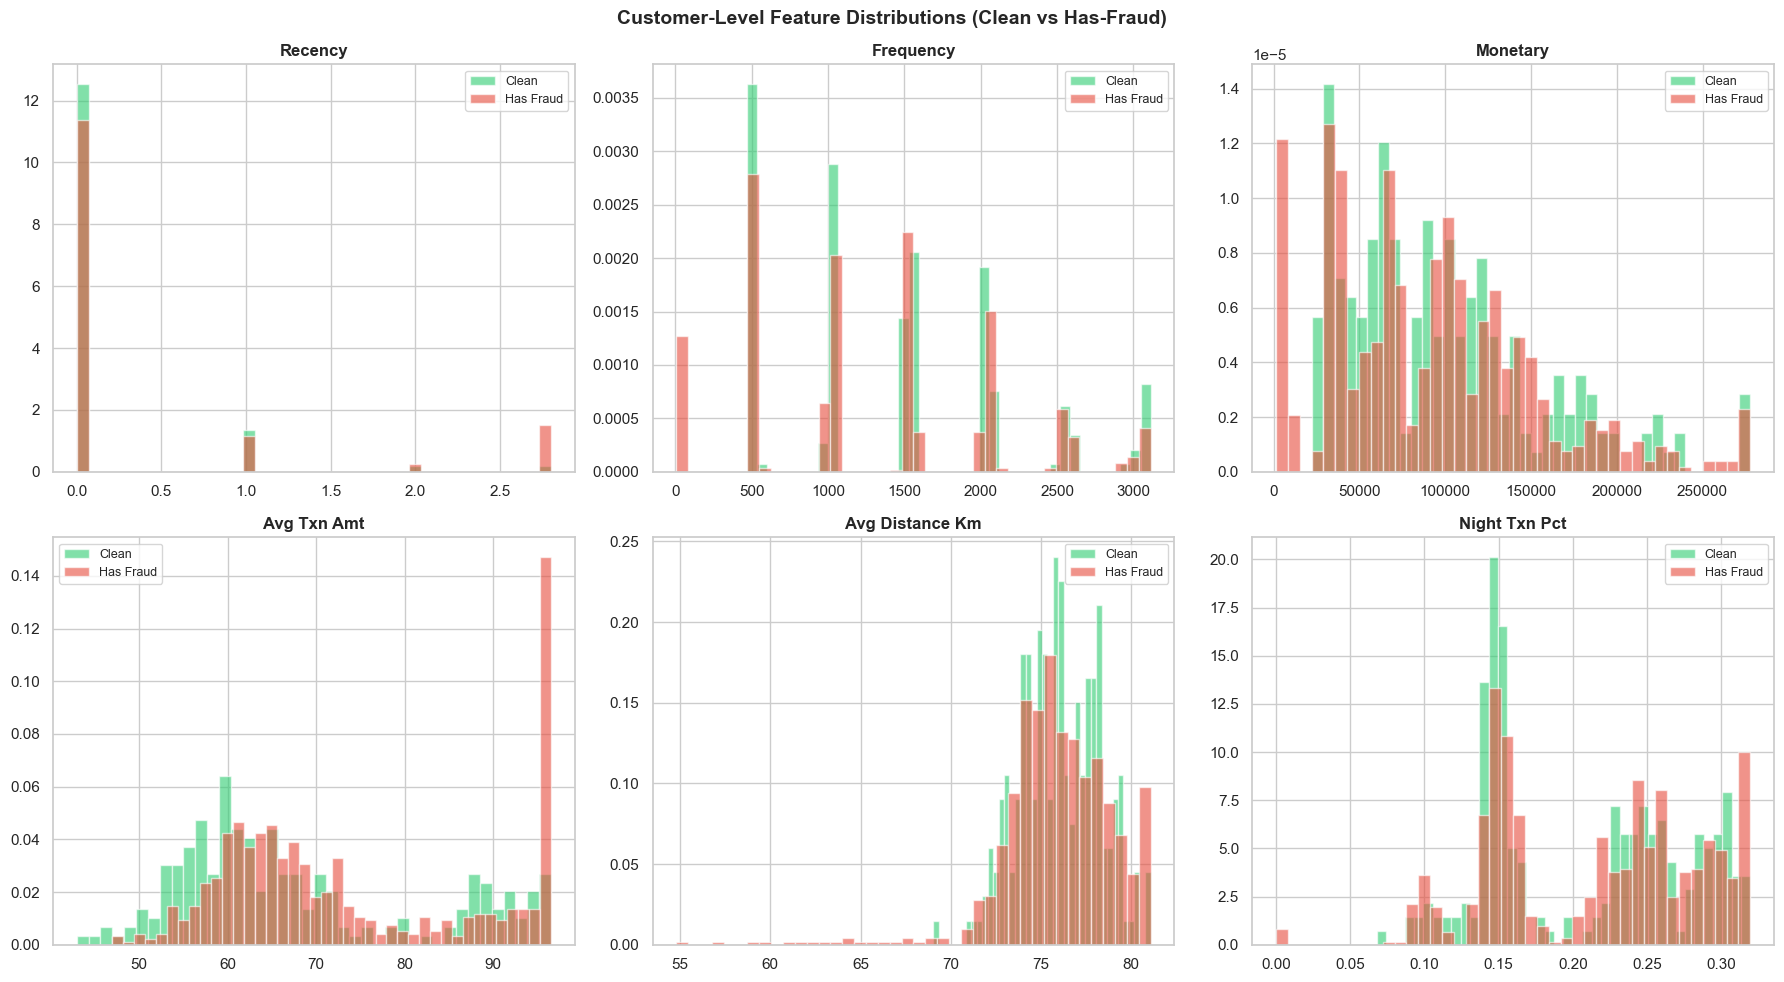

In [23]:
# Distribution of key customer-level features
rfm_cols = ['recency', 'frequency', 'monetary', 'avg_txn_amt', 'avg_distance_km', 'night_txn_pct']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(rfm_cols):
    legit_c = customer_df[customer_df['fraud_flag'] == 0][col]
    fraud_c = customer_df[customer_df['fraud_flag'] == 1][col]
    cap = legit_c.quantile(0.99)
    
    axes[i].hist(legit_c.clip(upper=cap), bins=40, alpha=0.6, color='#2ecc71', label='Clean', density=True)
    axes[i].hist(fraud_c.clip(upper=cap), bins=40, alpha=0.6, color='#e74c3c', label='Has Fraud', density=True)
    axes[i].set_title(col.replace('_', ' ').title(), fontweight='bold')
    axes[i].legend(fontsize=9)

plt.suptitle('Customer-Level Feature Distributions (Clean vs Has-Fraud)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/10_customer_features.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 11. Correlation Heatmap — Customer Level

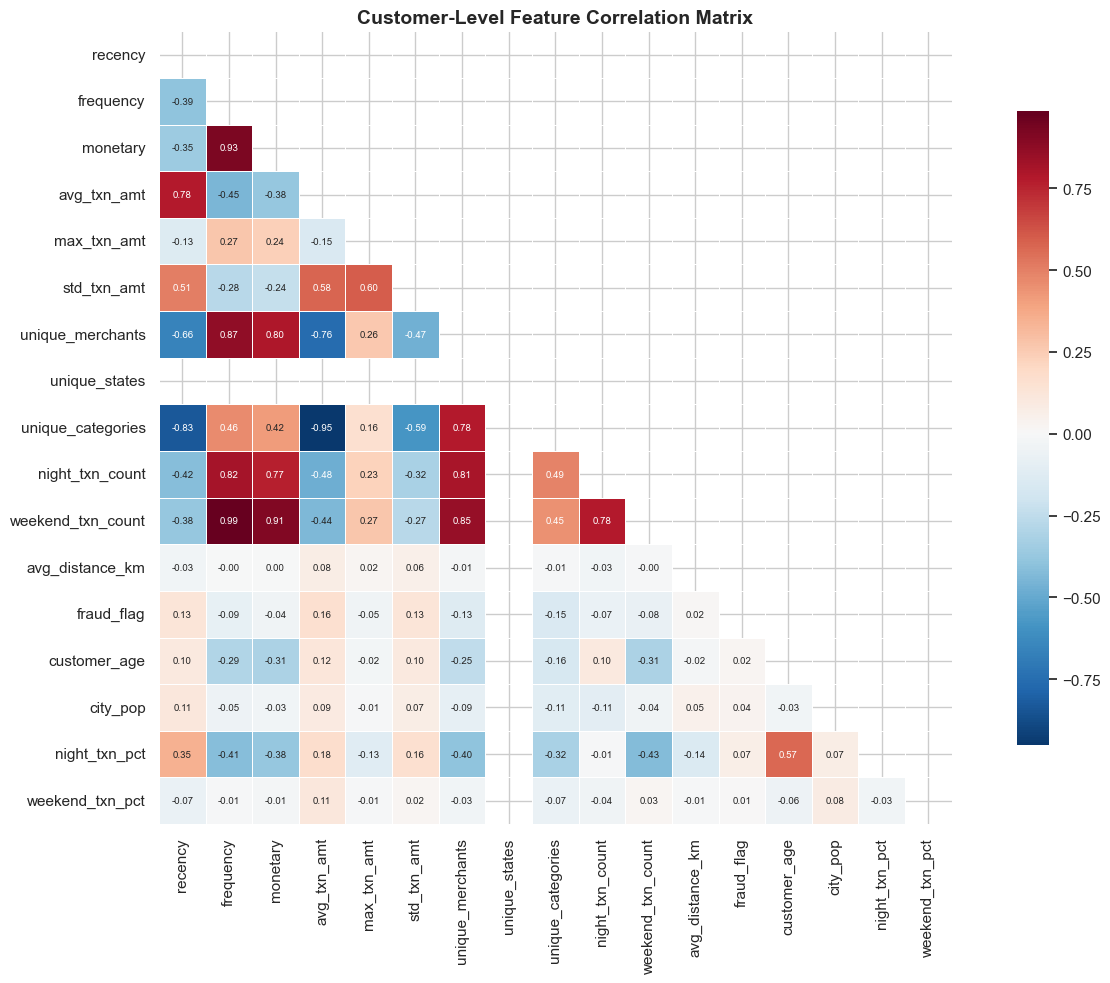

In [24]:
numeric_customer = customer_df.select_dtypes(include=np.number).drop(columns=['cc_num', 'fraud_txn_count'])
corr = numeric_customer.corr()

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, square=True,
    linewidths=0.5, annot_kws={'size': 7},
    cbar_kws={'shrink': 0.8}
)
plt.title('Customer-Level Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/11_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

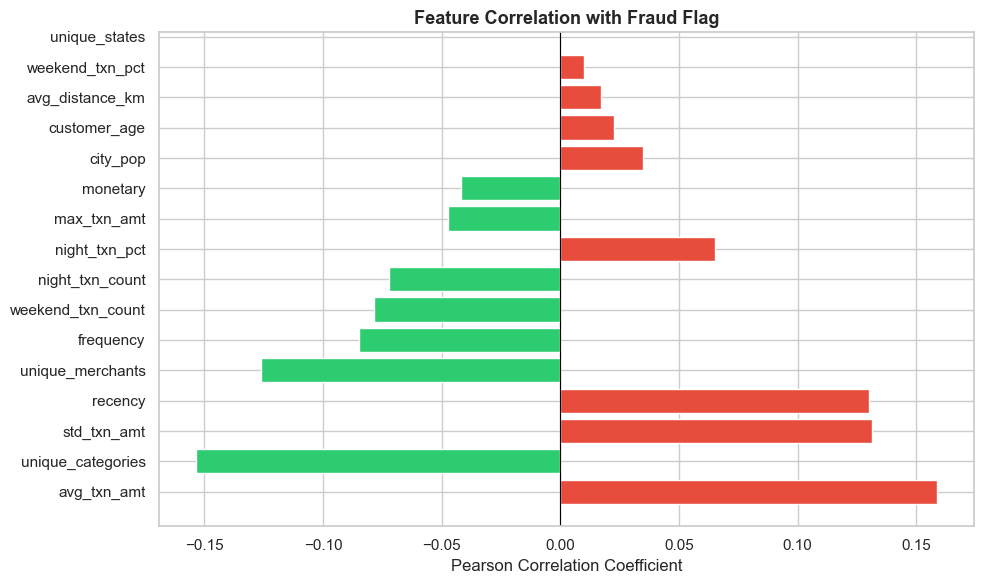

In [25]:
# Features most correlated with fraud flag
fraud_corr = corr['fraud_flag'].drop('fraud_flag').sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in fraud_corr.values]
plt.barh(fraud_corr.index, fraud_corr.values, color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Correlation with Fraud Flag', fontsize=13, fontweight='bold')
plt.xlabel('Pearson Correlation Coefficient')
plt.tight_layout()
plt.savefig('plots/12_fraud_correlation.png', dpi=150, bbox_inches='tight')
plt.show()